# ApproxMC count distributions

A quick notebook to visualise the distributions of model counts obtained by ApproxMC with different seeds. This serves as a quick study into whether we might use a Kolmogorov-Smirnov test to see if the distribution is much different from what we expect based on the chosen tolerance $\epsilon$ and confidence $\delta$. 

We will use $c$ to denote the random variable that is the approximate model count obtained by ApproxMC. We will, for now, assume that the distribution will be a normal one, with mean $\mu_c = c^*$, where $c^*$ is the true count, and $\sigma_c = ?$. Maybe $\sigma_c = \epsilon \cdot c^*$, but we should dive into the exact mathematics of ApproxMC's approximation guarantees to come up with something more appropriate.

First, let us load the libraries:

In [122]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import resource
import seaborn as sns
import time
import subprocess
import sys
from collections import namedtuple
from functools import partial
from scipy.stats import kstest, norm

sys.path.append('../')
from fuzz import Solver

In [82]:
Options = namedtuple("Options", "epsilon delta maxtime maxtimediff verbose", defaults=[0.8, 0.1, 5, 3, False])
options = Options()

In [87]:
def setlimits(t):
    # Set maximum CPU time to 1 second in child process, after fork() but before exec()
    print("Setting resource limit in child (pid %d)" % os.getpid())
    resource.setrlimit(resource.RLIMIT_CPU, (t, t))
    
def run(command, dir):
    print("Executing: %s in dir %s" % (" ".join(command), dir))
    if options.verbose:
        print("CPU limit of parent (pid %d)" % os.getpid(), resource.getrlimit(resource.RLIMIT_CPU))

    p = subprocess.Popen(command, stderr=subprocess.STDOUT,
          stdout=subprocess.PIPE, universal_newlines=True, cwd=dir,
          preexec_fn=partial(setlimits, options.maxtime))

    consoleOutput, err = p.communicate()
    if options.verbose:
        print("CPU limit of parent (pid %d) after child finished executing" % os.getpid(),
            resource.getrlimit(resource.RLIMIT_CPU))
    return consoleOutput, err


def run_one_counter(solver, fname, seed=42):
    curr_time = time.time()
    toexec = solver.exe.split()
    toexec.append(os.getcwd() + "/" + fname)
    if not solver.exact:
        toexec.extend(["--epsilon", str(options.epsilon),
                       "--delta", str(options.delta),
                       "-s", str(seed)])
    out, err = run(toexec, solver.dir)
    if err is not None and err.strip() != "":
        print("Error string is: ", err)
    diff_time = time.time() - curr_time
    if diff_time > options.maxtime - options.maxtimediff:
        print("Too much time to solve with %s, aborted!" % solver.exe)
        return None

    num = None
    for l in out.split("\n"):
        l = l.strip()
        print(l)
        if len(l) < 4:
            continue
        if l[0] == 'c' and l[:3] != "c s":
            continue
        if l[:4] == "s mc" or l[:13] == "c s exact arb":
            if num is not None:
                print("ERROR: Two 's mc' lines in output!!")
                # TODO: print command that got executed
                exit(-1)
            if l[:4] == "s mc":
                num = int(l.split()[2])
            elif l[:13] == "c s exact arb":
                num = int(l.split()[5])
            else:
                print("ERROR")
                exit(-1)
    if num is None:
        print("ERROR, could not find 's mc' or 'c s exact arb int' in output")
        exit(-1)

    return num

We will use the CDFs, because that way we don't have to create a histogram, so we need a function to turn a list of counts into a CDF:

In [2]:
def ecdf(samples):
    """ From https://stackoverflow.com/questions/24788200/calculate-the-cumulative-distribution-function-cdf-in-python """
    x, counts = np.unique(samples, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

And we need a function to obtain the true count:

In [93]:
def get_true_count(cnf_file):
    solver = Solver("../../ganak/build/ganak", True)
    count = run_one_counter(solver, cnf_file.replace('sandbox/', ''))
    return count

We also need a function to read the stored counts from file:

In [66]:
def get_data(result_file):
    data = dict()
    with open(result_file, 'r') as f:
        data = json.load(f)
    seeds, counts = zip(*data['samples'])
    data['counts'] = counts
    data['true_count'] = get_true_count(data['fname2'])
    return data

We need a function to plot the histogram and some extra data:

In [120]:
def plot_hist_and_fit(data):
    # Fit a normal distribution to the data:
    mu, std = norm.fit(data['counts'])

    # Plot the histogram.
    plt.hist(data['counts'], bins=21, density=True, alpha=0.6, color='g')

    # Plot the PDF.
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    
    # Plot the true count
    y = np.linspace(0, max(p)*1.5)
    x = [data['true_count']] * len(y)
    plt.plot(x, y, 'r', linewidth=2)

# mean_c = np.mean(counts)
# stdev_c = 0.1 * epsilon * mean_c / 1.65
# p = norm.pdf(x, mean_c, stdev_c)
# plt.plot(x, p, 'r', linewidth=2)

    title = "Fit: mu = %.0f, std = %.0f. True: c* = %.0f, stdc* = %.0f" % \
        (mu, std, data['true_count'], data['epsilon'] * data['true_count'] / 1.65)
    plt.title(title)

    plt.savefig(f"{data['fname2'].replace('sandbox/', '')}.{data['true_count']}.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

If we use $\delta = 0.1$, this essentially means that we have a confidence interval of $90\%$. Hence, we could use $\sigma = \frac{\epsilon}{1.65} * \mu_c$ to obtain a best guess for the standard deviation of the distribution. However, this tends to be much larger than the standard deviation measured from the measured data. The next couple of plots show a histogram of the measured data, along with a fitted normal distribution and a vertical line to indicate the true count. In the title, I've added the fitted parameters (mu and std), and the true count (c*) and best guess for the std, computed as $\sigma = \frac{\epsilon}{1.65} * \mu_c$.

fuzzTest_40.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_40.cnf in dir None
Setting resource limit in child (pid 188663)
fuzzTest_40.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_40.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY

Setting resource limit in child (pid 188673)
fuzzTest_40.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_40.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-r

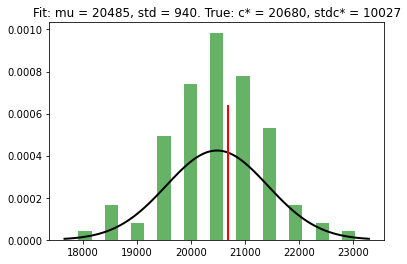

fuzzTest_3.cnf
fuzzTest_4.cnf
fuzzTest_48.cnf.25310.pdf
fuzzTest_41.cnf
fuzzTest_28.cnf
fuzzTest_50.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_50.cnf in dir None
Setting resource limit in child (pid 188678)
fuzzTest_3.cnf
fuzzTest_4.cnf
fuzzTest_48.cnf.25310.pdf
fuzzTest_41.cnf
fuzzTest_28.cnf
fuzzTest_50.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_50.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wpare

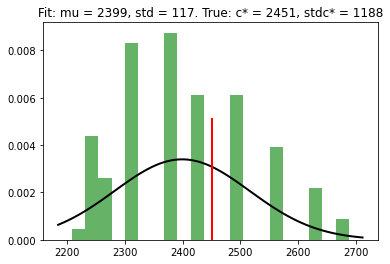

fuzzTest_25.cnf
fuzzTest_45.cnf
fuzzTest_36.cnf.json
Setting resource limit in child (pid 188683)
fuzzTest_25.cnf
fuzzTest_45.cnf
fuzzTest_36.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_36.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 

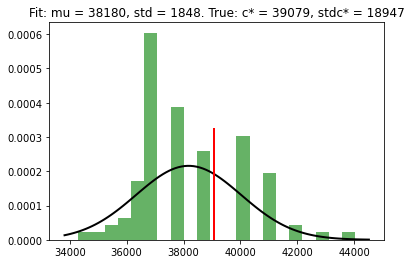

fuzzTest_43.cnf
fuzzTest_6.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_6.cnf in dir None
Setting resource limit in child (pid 188688)
fuzzTest_43.cnf
fuzzTest_6.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_6.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  |

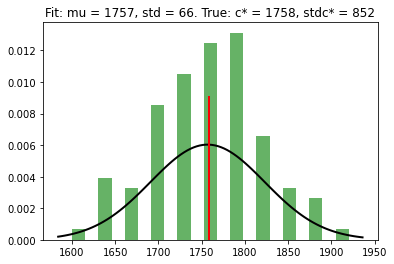

fuzzTest_6.cnf
fuzzTest_35.cnf
fuzzTest_27.cnf
fuzzTest_44.cnf.2271.pdf
fuzzTest_22.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_22.cnf in dir None
Setting resource limit in child (pid 188698)
fuzzTest_6.cnf
fuzzTest_35.cnf
fuzzTest_27.cnf
fuzzTest_44.cnf.2271.pdf
fuzzTest_22.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_22.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb

c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_34.cnf
c variables (all/used/free): 	40/40/0
c clauses (all/long/binary/unit): 257/252/5/0
c Sampling set not present! So doing total model counting.
c
c Preprocessing ..
c DONE
c variable

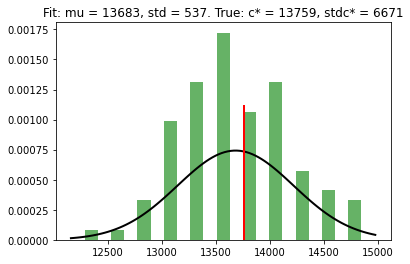

fuzzTest_50.cnf.2451.pdf
fuzzTest_12.cnf
fuzzTest_31.cnf
fuzzTest_7.cnf
fuzzTest_34.cnf
fuzzTest_10.cnf
fuzzTest_12.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_12.cnf in dir None
fuzzTest_50.cnf.2451.pdf
fuzzTest_12.cnf
fuzzTest_31.cnf
fuzzTest_7.cnf
fuzzTest_34.cnf
fuzzTest_10.cnf
fuzzTest_12.cnf.json
Setting resource limit in child (pid 188730)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLI

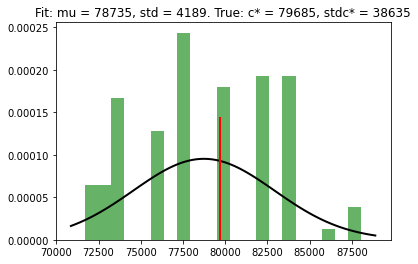

fuzzTest_5.cnf
fuzzTest_16.cnf
fuzzTest_34.cnf.13759.pdf
fuzzTest_28.cnf.24864.pdf
fuzzTest_26.cnf.20680.pdf
fuzzTest_30.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_30.cnf in dir None
Setting resource limit in child (pid 188737)
fuzzTest_5.cnf
fuzzTest_16.cnf
fuzzTest_34.cnf.13759.pdf
fuzzTest_28.cnf.24864.pdf
fuzzTest_26.cnf.20680.pdf
fuzzTest_30.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_30.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-ar

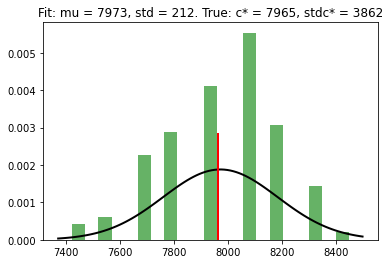

fuzzTest_18.cnf
fuzzTest_19.cnf
fuzzTest_47.cnf
fuzzTest_20.cnf
fuzzTest_39.cnf
fuzzTest_8.cnf
fuzzTest_42.cnf
fuzzTest_48.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_48.cnf in dir None
Setting resource limit in child (pid 188742)
fuzzTest_18.cnf
fuzzTest_19.cnf
fuzzTest_47.cnf
fuzzTest_20.cnf
fuzzTest_39.cnf
fuzzTest_8.cnf
fuzzTest_42.cnf
fuzzTest_48.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_48.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointe

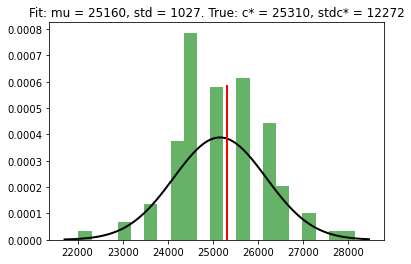

Setting resource limit in child (pid 188750)
fuzzTest_13.cnf
fuzzTest_40.cnf
fuzzTest_17.cnf
fuzzTest_30.cnf.7965.pdf
fuzzTest_36.cnf.39079.pdf
fuzzTest_14.cnf
fuzzTest_32.cnf
fuzzTest_46.cnf
fuzzTest_2.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_2.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilatio

Setting resource limit in child (pid 188760)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_14.cnf
c variables (all/used/free): 	10/10/0
c clauses (all/long/binary/unit): 34/29/5/0
c Sampling set not present! So doing total model count

Setting resource limit in child (pid 188770)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_14.cnf
c variables (all/used/free): 	10/10/0
c clauses (all/long/binary/unit): 34/29/5/0
c Sampling set not present! So doing total model count

Setting resource limit in child (pid 188775)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_14.cnf
c variables (all/used/free): 	10/10/0
c clauses (all/long/binary/unit): 34/29/5/0
c Sampling set not present! So doing total model count

Setting resource limit in child (pid 188780)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_14.cnf
c variables (all/used/free): 	10/10/0
c clauses (all/long/binary/unit): 34/29/5/0
c Sampling set not present! So doing total model count

Setting resource limit in child (pid 188785)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_14.cnf
c variables (all/used/free): 	10/10/0
c clauses (all/long/binary/unit): 34/29/5/0
c Sampling set not present! So doing total model count

c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_18.cnf
c variables (all/used/free): 	15/15/0
c clauses (all/long/binary/unit): 56/52/4/0
c Sampling set not present! So doing total model counting.
c
c Preprocessing ..
c DONE
c variables 

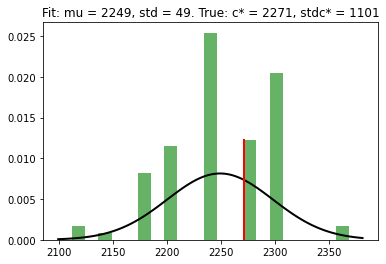

fuzzTest_24.cnf.1758.pdf
fuzzTest_2.cnf
fuzzTest_36.cnf
fuzzTest_46.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_46.cnf in dir None
Setting resource limit in child (pid 188795)
fuzzTest_24.cnf.1758.pdf
fuzzTest_2.cnf
fuzzTest_36.cnf
fuzzTest_46.cnf.json
Executing: ../../ganak/build/ganak /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_46.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICC

Setting resource limit in child (pid 188805)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: 18af6360fbb3e4899bc0a6135fd9167c08f10a19
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = ON | MY_TARGETS =  | compilation date time = Nov 21 2022 16:16:10
c Setting the timout to: 100000
c Solving /home/anna/NUS/projects/count-fuzzer/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_32.cnf
c variables (all/used/free): 	32/32/0
c clauses (all/long/binary/unit): 197/189/8/0
c Sampling set not present! So doing total model cou

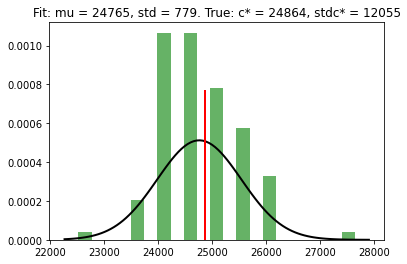

<Figure size 432x288 with 0 Axes>

In [121]:
result_dir = 'approxmc-results/nopreproc/'
for result_file in os.listdir(result_dir):
    print(result_file)
    if not result_file.endswith('.json'):
        continue
    data = get_data(f"{result_dir}{result_file}")
    print(data)
    if np.mean(data['counts']) < 1000:
        continue
    plot_hist_and_fit(data)